In [193]:
import sys
import os 

import pandas as pd 
import matplotlib.pyplot as plt 

sys.path.append(os.path.abspath(".."))

# LOADING THE DATASET FOR ANALYSIS

In [194]:
from src.data.load_data import load_raw_data

df = load_raw_data("../data/raw/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


* Each data point in the dataset represents a single product purchased by a customer as  
part of a specific transaction.  

* Multiple products may add up in a single transaction,  
  resulting in multiple data points for the same purchase. 

* The dataset is therefore at a transaction-line level.  

In [195]:
print("Initial data points present in the dataset: ",df.shape)

Initial data points present in the dataset:  (541909, 8)


## DATA QUALITY ANALYSIS 

**1. MISSING VALUE ANALYSIS**

In [196]:
df.isnull().mean()

InvoiceNo      0.000000
StockCode      0.000000
Description    0.002683
Quantity       0.000000
InvoiceDate    0.000000
UnitPrice      0.000000
CustomerID     0.249267
Country        0.000000
dtype: float64

* CustomerID: ~25.0% missing  
* Description: ~0.26% missing  

In [197]:
df[df["CustomerID"].isnull()].head()

df[df["CustomerID"].isnull()].describe()

df[df["CustomerID"].isnull()]["Country"].value_counts()

Country
United Kingdom    133600
EIRE                 711
Hong Kong            288
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                2
Name: count, dtype: int64

Rows with missing CustomerID appears to represent transactions without a  
unique customer identifier. These may corresponds to guest users or  
anonymous purchases. Hence, these rows are unsuitable for customer-level modeling.  

In [198]:
customerID_missing = df["CustomerID"].isnull().mean()*100
description_missing = df["Description"].isnull().mean()*100

print(f"Total Data points affected due to missing values of CustomerIDs: {customerID_missing}")
print(f"Total Data points affected due to missing Descriptions: {description_missing}")

Total Data points affected due to missing values of CustomerIDs: 24.926694334288598
Total Data points affected due to missing Descriptions: 0.2683107311375157


**COMBINED IMPACT :**  

In [199]:
affected_points = ((df["CustomerID"].isnull()) | (df["Description"].isnull())).mean()*100

print("Total number of data points having either missing Descriptions or customerID: ", affected_points)

Total number of data points having either missing Descriptions or customerID:  24.926694334288598


Approximately 24.93% of the dataset contains missing values in either  
CustomerID or Description, indicating that 24.93% of the data points from the datasets  
may not be usable for certian analysis.

**BAR PLOT**

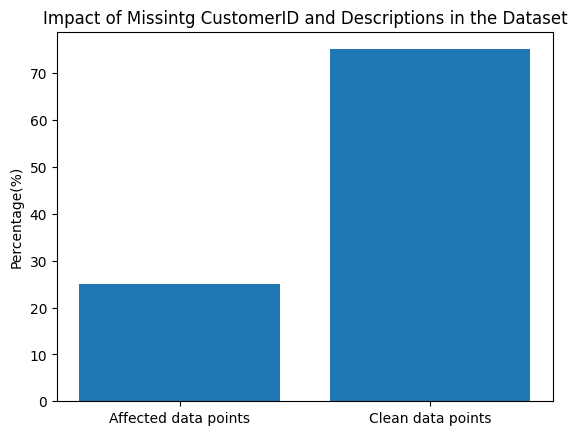

In [200]:
clean_points = 100 - affected_points

plt.bar(["Affected data points", "Clean data points"], [affected_points, clean_points])
plt.title("Impact of Missintg CustomerID and Descriptions in the Dataset")
plt.ylabel("Percentage(%)")

plt.show()

**Final Insight**
* The missing CustomerID values are not random but structurally missing,  
  indicating a specific class of transactions rather than data curruption.  
* CustomerID missing values represent transactions without identfiable customers.  
* These records cannot be used for customer-level feature engineering.  
* Description missing values are minimal.  
* A significant portion (~25%) of the dataset is affected by missing  
  CustomerID, which influence downstream modeling decisions. 

**Cleaning missing values from the dataset**  
df_rmr (DataFrame with removed missing values)

In [201]:
df_rmr = df.dropna(subset=["CustomerID", "Description"])

In [202]:
print("Total data points after dropping points containing missing CustomerID and Descriptions: ", df_rmr.shape)

Total data points after dropping points containing missing CustomerID and Descriptions:  (406829, 8)


**2. DATA TYPE CONSISTENCY**

In [203]:
df_rmr.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [204]:
df_rmr["CustomerID"].apply(type).value_counts()

CustomerID
<class 'float'>    406829
Name: count, dtype: int64

Converting CustomerID feature into an int type to avoid future failures 

In [205]:
df_rmr["CustomerID"] = df_rmr["CustomerID"].astype(int)

C:\Users\rachit\AppData\Local\Temp\ipykernel_32240\3262758149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rmr["CustomerID"] = df_rmr["CustomerID"].astype(int)


In [206]:
df_rmr["CustomerID"].apply(type).value_counts()

CustomerID
<class 'int'>    406829
Name: count, dtype: int64

In [207]:
df_rmr.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

Data types were verified for consistency across all columns.  
InvoiceDate is correctly stored as datetime for time-based analysis.  
Numerical features such as Quantity and UnitPrice for aggregation.  
CustomerID converted to string to represent it as a categorical identifier.  
All columns are now consistent and ready for further analysis. 

**3. INVALID & CORRUPTED DATA**

In [208]:
df_rmr.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,406829.000000,406829,406829.000000,406829.000000
mean,12.061303,2011-07-10 16:30:57.879207424,3.460471,15287.690570
min,-80995.000000,2010-12-01 08:26:00,0.000000,12346.000000
25%,2.000000,2011-04-06 15:02:00,1.250000,13953.000000
50%,5.000000,2011-07-31 11:48:00,1.950000,15152.000000
75%,12.000000,2011-10-20 13:06:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,248.693370,NaN,69.315162,1713.600303


In [209]:
df_rmr["InvoiceNo"].astype(str).str.startswith("C").mean()*100

np.float64(2.188880340388714)

Approximately 1.7% of transactions corresponds to the cancelled invoices.  
Cancelled invoices are removed to ensure that only valid purchase transactions  
are retained.  

Removing the points with cancelled invoices. 

In [210]:
cancelled_mask = df_rmr["InvoiceNo"].astype(str).str.startswith("C")
df_canc_inv= df_rmr[~cancelled_mask]

In [211]:
print("Total data points after dropping points with cancelled invoices: ", df_canc_inv.shape)

Total data points after dropping points with cancelled invoices:  (397924, 8)


Resetting the indices

In [212]:
df_canc_inv = df_canc_inv.reset_index(drop = True)

In [213]:
print("Data points with respect to the cancelled invoices: \n")
print("Before: ", len(df_rmr))
print("After: ", len(df_canc_inv))


Data points with respect to the cancelled invoices: 

Before:  406829
After:  397924


In [214]:
df_canc_inv["StockCode"].value_counts()

StockCode
85123A    2035
22423     1724
85099B    1618
84879     1408
47566     1397
          ... 
90214Z       1
90214U       1
23449        1
90214W       1
23843        1
Name: count, Length: 3665, dtype: int64

In [215]:
df_canc_inv["StockCode"].unique()[30:50]

array([21883, 10002, 21791, 21035, 22326, 22629, 22659, 22631, 22661,
       21731, 22900, 21913, 22540, 22544, 22492, 'POST', 22086, 20679,
       37370, 21871], dtype=object)

Certain StockCode values such as "POST" represents no-product entries  
like shipping charges. These are retained at this stage as they contribute  
to total transaction value but may be excluded in product-specific analyses later. 

In [216]:
print("Total number of data points with -ve quantities: ", (df_canc_inv["Quantity"] < 0 ).sum())
print("Minimum quantitiy of a product in a transaction: ", (df_canc_inv["Quantity"]).min())

Total number of data points with -ve quantities:  0
Minimum quantitiy of a product in a transaction:  1


In [217]:
(df["Quantity"] <= 0 ).sum()

np.int64(10624)

In [218]:
(df_canc_inv["Quantity"] <= 0 ).sum()

np.int64(0)

This represents that Negative quantity values were not observed after  
removing cancelled invoices and missing values, indicating that return transactions  
were already excluded during earlier cleaning steps. 

In [219]:
df_canc_inv["InvoiceDate"].dtype

dtype('<M8[ns]')

InvoiceDate represents the timestamp of transactions and is correctly   
formatted as datetime. No inconsistencies observed.  

In [220]:
df_canc_inv["UnitPrice"].min()

np.float64(0.0)

In [221]:
(df_canc_inv["UnitPrice"] == 0).sum()

np.int64(40)

There exists data points where UnitPrice of products is given 0.  
These data points possess no quality to be trained with,  
so removing them is the viable option.  

Removing the data points containing product UnitPrice = 0.

In [222]:
df_inv_price = df_canc_inv[df_canc_inv["UnitPrice"]  > 0]

In [223]:
df_inv_price = df_inv_price.reset_index(drop = True)

In [224]:
print("Total data points after dropping points containing products of UnitPrice = 0: ", df_inv_price.shape)

Total data points after dropping points containing products of UnitPrice = 0:  (397884, 8)


In [225]:
df_inv_price["Country"].unique()

array(['United Kingdom', 'France', 'Australia', 'Netherlands', 'Germany',
       'Norway', 'EIRE', 'Switzerland', 'Spain', 'Poland', 'Portugal',
       'Italy', 'Belgium', 'Lithuania', 'Japan', 'Iceland',
       'Channel Islands', 'Denmark', 'Cyprus', 'Sweden', 'Finland',
       'Austria', 'Greece', 'Singapore', 'Lebanon',
       'United Arab Emirates', 'Israel', 'Saudi Arabia', 'Czech Republic',
       'Canada', 'Unspecified', 'Brazil', 'USA', 'European Community',
       'Bahrain', 'Malta', 'RSA'], dtype=object)

In [226]:
(df_inv_price["Country"] == "Unspecified").sum()

np.int64(244)

Data points having transaction of products from "Unspecified" country  
are no use in any means to the system . 

Removing the data points containing Unspecified country

In [227]:
df_clean = df_inv_price[df_inv_price["Country"] != "Unspecified"]

In [228]:
df_clean = df_clean.reset_index(drop = True)

In [229]:
print("Total data points after dropping points containing country = 'Unspecified': ", df_clean.shape)

Total data points after dropping points containing country = 'Unspecified':  (397640, 8)


**DUPLICATES**

In [230]:
# Check duplicates
print("Duplicate rows:", df_clean.duplicated().sum()) 

Duplicate rows: 5189


In [231]:
# Remove duplicates
df_clean = df_clean.drop_duplicates()

print("After removing duplicates:", df_clean.shape)

After removing duplicates: (392451, 8)


# TRANSACTION ANALYSIS 

In [232]:
df_clean.shape

(392451, 8)